# COMP6010 C2 — Fresh 64-seed evaluation
Sayuru Bopitiya · 24071158

**Purpose:** strengthen the evidence using saved epoch-50 and epoch-250 checkpoints, without training again.
Compare **50 epochs / 50 Euler steps**, **250 / 50**, and **250 / 20** on seeds **19001–19064**.
These seeds are distinct from the original 9001–9016. This is a new follow-up evaluation informed by the earlier results, not a retrospectively preregistered original experiment.

## Run order
1. Select a Colab GPU if available (CPU also works). Run setup and load the existing checkpoints.
2. Write your own predictions in **Section 2** before generating images. Do not copy an invented past prediction.
3. Run generation, then score all **192** shuffled images in the scoring panel. Scores save after every click to Google Drive by default.
4. Run analysis after scoring, then export and download the results ZIP. Also download this notebook **with outputs**.

No dataset download or retraining is needed. Preserve the original experiment and report until this evaluation is complete.

## 1. Setup and recover saved checkpoints

In [27]:
from pathlib import Path
from datetime import datetime, timezone
import json, math, hashlib, time, sys, os, zipfile, shutil, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from scipy.stats import binomtest

SAVE_TO_DRIVE = True
RUN_NAME = 'cat_eval64_v1'  # Keep this name to resume ratings; a changed protocol needs a NEW name.
CHECKPOINT_DIR = ''  # Optional explicit folder containing checkpoint_epoch_50.pt and checkpoint_epoch_250.pt.
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/COMP6010')
else:
    BASE = Path.cwd() / 'COMP6010'
RUN = BASE / RUN_NAME
RUN.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(min(4, os.cpu_count() or 1))
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
CONFIGS = [('early50_steps50', 50, 50), ('late250_steps50', 250, 50), ('late250_steps20', 250, 20)]
SEEDS = list(range(19001, 19065))
BATCH = 16  # Same inference batch size as the original experiment.
REPEATS = 5
SHUFFLE_SEED = 601028
BOOTSTRAP_SEED = 601029
BOOTSTRAP_REPEATS = 20000
VERSIONS = {p: importlib.metadata.version(p) for p in ['torch','numpy','pandas','matplotlib','scipy']}
def utc_now(): return datetime.now(timezone.utc).isoformat()
def digest(path):
    h = hashlib.sha256()
    with open(path,'rb') as f:
        for block in iter(lambda:f.read(1024*1024), b''): h.update(block)
    return h.hexdigest()
def save_json(path, value):
    tmp = path.with_suffix(path.suffix+'.tmp')
    tmp.write_text(json.dumps(value, indent=2))
    os.replace(tmp,path)
def save_csv(path, frame):
    tmp = path.with_suffix(path.suffix+'.tmp')
    frame.to_csv(tmp,index=False); os.replace(tmp,path)
print('Device:', DEVICE, '| Versions:', VERSIONS)
print('Results:', RUN)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda | Versions: {'torch': '2.11.0+cu128', 'numpy': '2.1.3', 'pandas': '2.2.3', 'matplotlib': '3.10.0', 'scipy': '1.16.3'}
Results: /content/drive/MyDrive/COMP6010/cat_eval64_v1


In [28]:
# First try the original Drive run. Otherwise upload cat_250_v1_results.zip OR the full supplement ZIP.
source = Path(CHECKPOINT_DIR) if CHECKPOINT_DIR else BASE/'cat_250_v1'
names = [f'checkpoint_epoch_{e}.pt' for e in [50,250]]
if not all((source/n).exists() for n in names):
    source = RUN/'restored_checkpoints'
    source.mkdir(exist_ok=True)
    if not all((source/n).exists() for n in names):
        from google.colab import files
        print('Upload cat_250_v1_results.zip or Sayuru_Bopitiya_24071158_COMP6010_Supplement.zip')
        uploaded = files.upload()
        archives = [Path(k) for k in uploaded if k.lower().endswith('.zip')]
        if len(archives)!=1: raise ValueError('Upload exactly one results/supplement ZIP.')
        with zipfile.ZipFile(archives[0]) as z:
            for n in names:
                preferred = 'C/extended250/'+n
                candidates = [m for m in z.namelist() if Path(m).name==n]
                member = preferred if preferred in candidates else (candidates[0] if len(candidates)==1 else None)
                if member is None: raise ValueError(f'Cannot identify the final-run copy of {n}.')
                # Copy only these two named checkpoint members; no arbitrary archive paths are extracted.
                with z.open(member) as inp, open(source/n,'wb') as out:
                    shutil.copyfileobj(inp,out)
        del uploaded
CHECKPOINTS = {e: source/f'checkpoint_epoch_{e}.pt' for e in [50,250]}
EXPECTED_HASHES = {'50': 'ac5a6108bbaca7d39210e1f9ea74a267a8214c4736f6a22edcf6fa89196c83cf', '250': 'a4907f275c56b23c43288b76e96fdbfa59666f2f548b67d5696f02a6b512c13e'}

for e,path in CHECKPOINTS.items():
    if digest(path)!=EXPECTED_HASHES[str(e)]:
        raise ValueError(f'Epoch {e} checkpoint differs from the reviewed original. Use the original saved checkpoint.')
print('Both original checkpoint hashes verified. No training will run.')

Both original checkpoint hashes verified. No training will run.


## 2. Record YOUR prediction before seeing the new outputs
Fill the two prediction strings below in your own words. Include your reasoning and acknowledge that you have seen the original 16-seed results. A prediction may be wrong; that is useful evidence.

The timestamp records when this follow-up prediction was saved. It does not repair or replace the earlier blank prediction fields.

In [29]:
PREDICTION_TRAINING = (
    "I expect the 250-epoch model to produce slightly more recognisable cats "
    "than the 50-epoch model. The earlier results showed lower held-out loss "
    "but only a small visual improvement, so I expect some ambiguous drawings "
    "to remain in the new sample."
)

PREDICTION_STEPS = (
    "I expect 20 Euler steps to generate images faster than 50 steps, "
    "with broadly similar recognisability but possibly less coherent detail "
    "in some drawings. I will check whether this holds across the new seeds."
)
PRIOR_CONTEXT = 'I have seen the previous 16-seed results and the report discussion.'
protocol_settings = {
    'version':1, 'configs':CONFIGS, 'seeds':SEEDS, 'batch_size':BATCH,
    'timing_repeats':REPEATS, 'shuffle_seed':SHUFFLE_SEED,
    'bootstrap_seed':BOOTSTRAP_SEED, 'bootstrap_repeats':BOOTSTRAP_REPEATS,
    'checkpoint_sha256':EXPECTED_HASHES,
    'primary_measure':'fraction of outputs with cat_score=2',
    'secondary_measure':'mean ordinal score, interpreted descriptively',
    'rubric':{'0':'No identifiable animal structure, blank or noise',
              '1':'Animal-like or cat fragments, but ambiguous or incoherent',
              '2':'Recognisable cat with coherent overall structure and identifying features'},
    'comparisons':{'training':'late250_steps50 minus early50_steps50',
                   'inference':'late250_steps20 minus late250_steps50'},
    'ci':'Wilson 95% intervals for recognisable proportions; paired percentile bootstrap 95% intervals for differences',
    'scope':'Conditional on these trained checkpoints and one rater; not training-seed or inter-rater uncertainty'}
protocol_settings = json.loads(json.dumps(protocol_settings))
protocol_path = RUN/'protocol.json'
if protocol_path.exists():
    protocol = json.loads(protocol_path.read_text())
    if protocol['settings']!=protocol_settings:
        raise ValueError('Saved protocol differs. Restore its settings or choose a new RUN_NAME.')
    print('Reusing locked prediction/protocol from',protocol['recorded_utc'])
else:
    if not PREDICTION_TRAINING.strip() or not PREDICTION_STEPS.strip():
        raise ValueError('Write both predictions above, then rerun this cell BEFORE generation.')
    protocol = {'recorded_utc':utc_now(),'settings':protocol_settings,
                'student_prediction_training':PREDICTION_TRAINING,
                'student_prediction_steps':PREDICTION_STEPS,'prior_context':PRIOR_CONTEXT}
    save_json(protocol_path,protocol)
print('Protocol saved. Original runs and ratings remain unchanged.')

Reusing locked prediction/protocol from 2026-09-28T04:12:40.644601+00:00
Protocol saved. Original runs and ratings remain unchanged.


## 3. Same velocity network and Euler solver

In [30]:
class TimeEmbedding(nn.Module):
    def __init__(self,dimension=64):
        super().__init__()
        self.register_buffer('frequencies',torch.exp(-math.log(10000)*torch.arange(dimension//2)/(dimension//2-1)))
        self.mlp=nn.Sequential(nn.Linear(dimension,128),nn.SiLU(),nn.Linear(128,128))
    def forward(self,t):
        angles=t[:,None]*self.frequencies[None,:]*1000
        return self.mlp(torch.cat([angles.sin(),angles.cos()],dim=1))

class TimeBlock(nn.Module):
    def __init__(self,input_channels,output_channels):
        super().__init__()
        self.conv1=nn.Conv2d(input_channels,output_channels,3,padding=1)
        self.norm1=nn.GroupNorm(8,output_channels)
        self.time=nn.Linear(128,output_channels)
        self.conv2=nn.Conv2d(output_channels,output_channels,3,padding=1)
        self.norm2=nn.GroupNorm(8,output_channels)
        self.skip=nn.Conv2d(input_channels,output_channels,1) if input_channels!=output_channels else nn.Identity()
    def forward(self,x,time_embedding):
        h=F.silu(self.norm1(self.conv1(x)))
        h=h+self.time(time_embedding)[:,:,None,None]
        h=self.norm2(self.conv2(F.silu(h)))
        return F.silu(h+self.skip(x))

class VelocityUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.time=TimeEmbedding()
        self.input=nn.Conv2d(1,32,3,padding=1)
        self.block28=TimeBlock(32,32)
        self.down14=nn.Conv2d(32,64,4,stride=2,padding=1)
        self.block14=TimeBlock(64,64)
        self.down7=nn.Conv2d(64,128,4,stride=2,padding=1)
        self.middle=TimeBlock(128,128)
        self.up14=TimeBlock(128+64,64)
        self.up28=TimeBlock(64+32,32)
        self.output=nn.Conv2d(32,1,3,padding=1)
    def forward(self,x,t):
        embedding=self.time(t)
        skip28=self.block28(self.input(x),embedding)
        skip14=self.block14(self.down14(skip28),embedding)
        h=self.middle(self.down7(skip14),embedding)
        h=self.up14(torch.cat([F.interpolate(h,size=(14,14),mode='nearest'),skip14],dim=1),embedding)
        h=self.up28(torch.cat([F.interpolate(h,size=(28,28),mode='nearest'),skip28],dim=1),embedding)
        return self.output(h)

@torch.no_grad()
def euler_sample(model, initial, steps):
    if steps<1: raise ValueError('steps must be positive')
    model.eval()
    x = initial.clone()
    for k in range(steps):
        t = torch.full((len(x),), k/steps, device=x.device)
        x = x + model(x,t)/steps
    return x

def sync():
    if DEVICE.type=='cuda': torch.cuda.synchronize()

def load_network(epoch):
    cp = torch.load(CHECKPOINTS[epoch],map_location='cpu',weights_only=True)
    if cp['epoch']!=epoch or cp['training_id']['architecture']!='VelocityUNet_v1_32_64_128':
        raise ValueError('Unexpected checkpoint identity.')
    model = VelocityUNet().to(DEVICE)
    model.load_state_dict(cp['model'])
    assert sum(p.numel() for p in model.parameters())==819521
    return model.eval()

class ConstantVelocity(nn.Module):
    def forward(self,x,t): return torch.full_like(x,0.25)
x_test = torch.zeros(2,1,28,28,device=DEVICE)
assert torch.allclose(euler_sample(ConstantVelocity(),x_test,20),x_test+0.25,atol=1e-6)
print('Constant-velocity integration check passed.')

Constant-velocity integration check passed.


## 4. Generate and time all configurations
Images are not displayed here. Full arrays and configuration keys are retained for reproducibility, but do not inspect the key or labelled arrays while scoring. This is label-concealed self-rating, not a secure or independently administered double-blind study.

Timing uses five rounds, each with randomised configuration order. Each configuration is warmed up immediately before timing. Each timed evaluation generates all 64 images in batches of 16, with GPU synchronisation; loading, plotting and saving are excluded. Compare these new timings within this run; hardware may differ from the original T4 run.

In [31]:
if not protocol_path.exists(): raise RuntimeError('Save your predictions first.')
RAW = RUN/'raw_arrays'; RAW.mkdir(exist_ok=True)
complete_path = RUN/'generation_complete.json'
if complete_path.exists():
    saved = json.loads(complete_path.read_text())
    assert saved['protocol_sha256']==digest(protocol_path)
    for name,_,_ in CONFIGS:
        path = RAW/f'{name}.npy'
        assert digest(path)==saved['array_sha256'][name], 'Array changed after generation.'
        arr=np.load(path); assert arr.shape==(64,1,28,28) and np.isfinite(arr).all()
    print('Reusing saved arrays and timings; no regeneration.')
else:
    initial_cpu = torch.cat([torch.randn(1,1,28,28,generator=torch.Generator().manual_seed(s)) for s in SEEDS])
    initial = initial_cpu.to(DEVICE)
    np.save(RUN/'initial_noise.npy',initial_cpu.numpy())
    timing_rows=[]
    order_rng=np.random.default_rng(601030)
    for repeat in range(REPEATS):
        for config_index in order_rng.permutation(len(CONFIGS)):
            name,epoch,steps=CONFIGS[int(config_index)]
            model=load_network(epoch)
            euler_sample(model,initial[:BATCH],steps);sync()
            start=time.perf_counter()
            parts=[euler_sample(model,initial[i:i+BATCH],steps) for i in range(0,len(initial),BATCH)]
            sync();elapsed=time.perf_counter()-start
            if repeat==0:
                result=torch.cat(parts).cpu().numpy()
                assert result.shape==(64,1,28,28) and np.isfinite(result).all()
                np.save(RAW/f'{name}.npy',result)
            timing_rows.append({'configuration':name,'epoch':epoch,'steps':steps,'nfe_per_image':steps,
                                'repeat':repeat+1,'images':64,'batch_size':BATCH,'seconds_for_64':elapsed})
            del model,parts
        print(f'Timing round {repeat+1}/{REPEATS} complete (images remain concealed).')
    save_csv(RUN/'timing_repeats.csv',pd.DataFrame(timing_rows))
    save_json(complete_path,{'completed_utc':utc_now(),'protocol_sha256':digest(protocol_path),
        'array_sha256':{name:digest(RAW/f'{name}.npy') for name,_,_ in CONFIGS},
        'versions':VERSIONS,'python':sys.version,'device':str(DEVICE),
        'hardware':torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else 'CPU'})

# Shuffle all 192 records together and assign anonymous IDs. Preserve this fixed mapping on resume.
key_path=RUN/'configuration_key_DO_NOT_OPEN_UNTIL_SCORED.csv'
records=[{'configuration':name,'seed':seed,'array_index':i} for name,_,_ in CONFIGS for i,seed in enumerate(SEEDS)]
order=np.random.default_rng(SHUFFLE_SEED).permutation(len(records))
key=pd.DataFrame([{'image_id':f'IMG_{j+1:03d}',**records[int(i)]} for j,i in enumerate(order)])
if key_path.exists():
    pd.testing.assert_frame_equal(pd.read_csv(key_path),key)
else:save_csv(key_path,key)
ratings_path=RUN/'human_ratings.csv'
if not ratings_path.exists():
    save_csv(ratings_path,pd.DataFrame({'image_id':key.image_id,'cat_score':'','notes':'','rater':'','rated_utc':''}))
# Create a portable scoring booklet, with anonymous IDs only. Preserve raw arrays unmodified.
BLIND=RUN/'blinded_grids';BLIND.mkdir(exist_ok=True)
arrays={name:np.load(RAW/f'{name}.npy') for name,_,_ in CONFIGS}
for page_start in range(0,len(key),16):
    dest=BLIND/f'page_{page_start//16+1:02d}.png'
    if dest.exists():continue
    fig,axes=plt.subplots(4,4,figsize=(8,8))
    for ax,(_,row) in zip(axes.flat,key.iloc[page_start:page_start+16].iterrows()):
        im=arrays[row.configuration][int(row.array_index),0]
        ax.imshow(np.clip((im+1)/2,0,1),cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
        ax.set_title(row.image_id);ax.axis('off')
    fig.tight_layout();fig.savefig(dest,dpi=160);plt.close(fig)
print('192 outputs prepared. Continue to the scoring panel without opening the configuration key.')

Reusing saved arrays and timings; no regeneration.
192 outputs prepared. Continue to the scoring panel without opening the configuration key.


## 5. Score each image yourself
Use the same rubric throughout: **0** no identifiable animal; **1** ambiguous animal/cat fragments; **2** recognisable cat with coherent structure and identifying features. Do not require photographic anatomy, but avoid calling every pointy-eared shape a clear cat. Use notes for borderline cases.

Enter your name, click a score to save and move forward, and use Previous to revise. Closing Colab is safe when Drive saving is enabled. On reopening, run the cells above with the same RUN_NAME; saved predictions/arrays/ratings are reused. This panel resumes at the first unscored image. Do not reveal configuration labels until all 192 are scored.

If you prefer a spreadsheet, edit `human_ratings.csv` in the saved run folder using the anonymous booklet. Keep every ID, and fill cat_score, rater and rated_utc. Do not replace missing ratings with AI scores.

In [32]:
try:
    import ipywidgets as widgets
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable,'-m','pip','install','ipywidgets','-q'])
    import ipywidgets as widgets
from IPython.display import display, clear_output
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass
ratings=pd.read_csv(ratings_path,keep_default_na=False)
assert ratings.image_id.tolist()==key.image_id.tolist()
missing=pd.to_numeric(ratings.cat_score,errors='coerce').isna()
position={'i':int(np.flatnonzero(missing.to_numpy())[0]) if missing.any() else 0}
rater_box=widgets.Text(value='Sayuru Bopitiya',description='Rater:')
notes_box=widgets.Textarea(description='Notes:',layout=widgets.Layout(width='600px',height='65px'))
status=widgets.HTML();image_output=widgets.Output()
previous=widgets.Button(description='Previous');next_button=widgets.Button(description='Next / skip')
buttons=[widgets.Button(description=s) for s in ['0 — no animal','1 — ambiguous','2 — clear cat']]
def show_current():
    i=position['i'];row=key.iloc[i]
    count=int(pd.to_numeric(ratings.cat_score,errors='coerce').notna().sum())
    status.value=f'<b>{row.image_id}</b> · image {i+1}/192 · {count}/192 scored · saved score: {ratings.at[i,"cat_score"]}'
    notes_box.value=str(ratings.at[i,'notes'])
    with image_output:
        clear_output(wait=True)
        fig,ax=plt.subplots(figsize=(3.7,3.7))
        im=arrays[row.configuration][int(row.array_index),0]
        ax.imshow(np.clip((im+1)/2,0,1),cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
        ax.axis('off');plt.show();plt.close(fig)
def save_rating(score):
    if not rater_box.value.strip():
        status.value='Enter your rater name first.';return
    i=position['i']
    ratings.loc[i,['cat_score','notes','rater','rated_utc']]=[score,notes_box.value,rater_box.value.strip(),utc_now()]
    save_csv(ratings_path,ratings)
    position['i']=min(i+1,len(ratings)-1)
    show_current()
def move(delta):
    position['i']=max(0,min(len(ratings)-1,position['i']+delta));show_current()
for score,button in enumerate(buttons):button.on_click(lambda _,s=score:save_rating(s))
previous.on_click(lambda _:move(-1));next_button.on_click(lambda _:move(1))
display(widgets.VBox([rater_box,status,image_output,notes_box,widgets.HBox(buttons),widgets.HBox([previous,next_button])]))
show_current()

## 6. Reveal and analyse — run AFTER all 192 ratings are saved
The primary outcome is the proportion scored **2**. Wilson intervals describe finite-seed uncertainty for each configuration, conditional on the chosen model and rating procedure. For differences we resample **whole matched seeds**, keeping the two configurations paired, using 20,000 percentile-bootstrap resamples and seed 601029. Positive training difference favours epoch 250; positive inference difference favours 20 steps.

Intervals do not account for training-seed variation, rating bias or uncertainty across raters. A zero-width bootstrap interval means no empirical variation was observed, not proof of population equivalence. An interval spanning zero means the direction is uncertain; overlapping marginal intervals alone are not a paired comparison. No equivalence margin was specified, so do not claim that 20 and 50 steps are statistically equivalent.

Sources: [SciPy proportion intervals](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats._result_classes.BinomTestResult.proportion_ci.html) and [paired bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html). The transparent paired-difference bootstrap below resamples seed-level differences directly.

In [33]:
def validate_ratings(frame,key_frame):
    expected=set(key_frame.image_id)
    if len(frame)!=len(key_frame) or frame.image_id.duplicated().any() or set(frame.image_id)!=expected:
        raise ValueError('Ratings must contain every anonymous ID exactly once.')
    scores=pd.to_numeric(frame.cat_score,errors='coerce')
    if scores.isna().any():raise ValueError(f'Only {scores.notna().sum()}/{len(scores)} scored. Finish Section 5 first.')
    if not scores.isin([0,1,2]).all():raise ValueError('Every score must be 0, 1 or 2.')
    if frame.rater.astype(str).str.strip().eq('').any():raise ValueError('Rater names are required.')
    if pd.to_datetime(frame.rated_utc,utc=True,errors='coerce').isna().any():raise ValueError('Valid rating timestamps are required.')
    out=frame.copy();out['cat_score']=scores.astype(int)
    return out.merge(key_frame,on='image_id',validate='one_to_one')

def paired_difference(a,b,seed=BOOTSTRAP_SEED,repeats=BOOTSTRAP_REPEATS):
    a=np.asarray(a,dtype=float);b=np.asarray(b,dtype=float)
    if a.shape!=b.shape or a.ndim!=1 or not len(a):raise ValueError('Matched nonempty vectors required.')
    d=a-b
    indices=np.random.default_rng(seed).integers(0,len(d),size=(repeats,len(d)))
    resampled=d[indices].mean(axis=1)
    lo,hi=np.quantile(resampled,[0.025,0.975])
    return {'difference':float(d.mean()),'ci95_low':float(lo),'ci95_high':float(hi),
            'degenerate_bootstrap':bool(np.ptp(d)==0)}

def analyse_scored(merged):
    summaries=[]
    for name,epoch,steps in CONFIGS:
        g=merged[merged.configuration==name];assert len(g)==64
        k=int((g.cat_score==2).sum());ci=binomtest(k,len(g)).proportion_ci(method='wilson')
        summaries.append({'configuration':name,'epoch':epoch,'steps':steps,'n':len(g),
            'recognisable_count':k,'recognisable_fraction':k/len(g),'wilson95_low':ci.low,'wilson95_high':ci.high,
            'mean_score':g.cat_score.mean()})
    wide=merged.pivot(index='seed',columns='configuration',values='cat_score').sort_index()
    assert wide.index.tolist()==SEEDS and not wide.isna().any().any()
    comparisons=[];per_seed=[]
    for label,a,b in [('training','late250_steps50','early50_steps50'),('inference','late250_steps20','late250_steps50')]:
        av=wide[a].to_numpy();bv=wide[b].to_numpy()
        for metric,x,y in [('recognisable_fraction',(av==2).astype(float),(bv==2).astype(float)),('mean_score',av,bv)]:
            comparisons.append({'comparison':label,'a':a,'b':b,'metric':metric,
                                **paired_difference(x,y),
                                'improved_seeds':int((x>y).sum()),'tied_seeds':int((x==y).sum()),'worsened_seeds':int((x<y).sum())})
        for seed,x,y in zip(SEEDS,av,bv):per_seed.append({'comparison':label,'seed':seed,'a_score':int(x),'b_score':int(y),'difference':int(x-y)})
    return pd.DataFrame(summaries),pd.DataFrame(comparisons),pd.DataFrame(per_seed)

ANALYSIS_READY=False
frame=pd.read_csv(ratings_path,keep_default_na=False)
if pd.to_numeric(frame.cat_score,errors='coerce').isna().any():
    print('Scoring is incomplete. Return to Section 5; rerun this cell after all images are scored.')
else:
    merged=validate_ratings(frame,key)
    summary,comparisons,per_seed=analyse_scored(merged)
    save_csv(RUN/'ratings_unblinded.csv',merged)
    save_csv(RUN/'quality_summary.csv',summary)
    save_csv(RUN/'paired_comparisons.csv',comparisons)
    save_csv(RUN/'paired_seed_scores.csv',per_seed)
    timings=pd.read_csv(RUN/'timing_repeats.csv')
    timing_summary=timings.groupby('configuration').agg(median_seconds_for_64=('seconds_for_64','median'),std_seconds_for_64=('seconds_for_64','std'),repeats=('seconds_for_64','count')).reset_index()
    save_csv(RUN/'timing_summary.csv',timing_summary)
    speed=timing_summary.set_index('configuration').median_seconds_for_64
    ratio=float(speed['late250_steps50']/speed['late250_steps20'])
    save_json(RUN/'analysis_provenance.json',{'analysed_utc':utc_now(),'ratings_sha256':digest(ratings_path),
        'protocol_sha256':digest(protocol_path),'generation_metadata_sha256':digest(complete_path),
        'speed_ratio_50step_to_20step':ratio,'versions':VERSIONS})
    display(summary);display(comparisons);display(timing_summary)
    print(f'50-step / 20-step time ratio: {ratio:.3f}. These are new-run timings.')
    print('Your recorded training prediction:',protocol['student_prediction_training'])
    print('Your recorded inference prediction:',protocol['student_prediction_steps'])
    ANALYSIS_READY=True

,configuration,epoch,steps,n,recognisable_count,recognisable_fraction,wilson95_low,wilson95_high,mean_score
0,early50_steps50,50,50,64,1,0.015625,0.002764,0.083341,0.359375
1,late250_steps50,250,50,64,3,0.046875,0.016069,0.128997,0.531250
2,late250_steps20,250,20,64,1,0.015625,0.002764,0.083341,0.484375


,comparison,a,b,metric,difference,ci95_low,ci95_high,degenerate_bootstrap,improved_seeds,tied_seeds,worsened_seeds
0,training,late250_steps50,early50_steps50,recognisable_fraction,0.031250,-0.031250,0.093750,False,3,60,1
1,training,late250_steps50,early50_steps50,mean_score,0.171875,0.000000,0.343750,False,21,32,11
2,inference,late250_steps20,late250_steps50,recognisable_fraction,-0.031250,-0.078125,0.000000,False,0,62,2
3,inference,late250_steps20,late250_steps50,mean_score,-0.046875,-0.171875,0.078125,False,7,47,10


,configuration,median_seconds_for_64,std_seconds_for_64,repeats
0,early50_steps50,0.616756,0.010338,5
1,late250_steps20,0.248750,0.004470,5
2,late250_steps50,0.616164,0.003571,5


50-step / 20-step time ratio: 2.477. These are new-run timings.
Your recorded training prediction: I expect the 250-epoch model to produce slightly more recognisable cats than the 50-epoch model. The earlier results showed lower held-out loss but only a small visual improvement, so I expect some ambiguous drawings to remain in the new sample.
Your recorded inference prediction: I expect 20 Euler steps to generate images faster than 50 steps, with broadly similar recognisability but possibly less coherent detail in some drawings. I will check whether this holds across the new seeds.


## 7. Full labelled grids and a matched figure after scoring

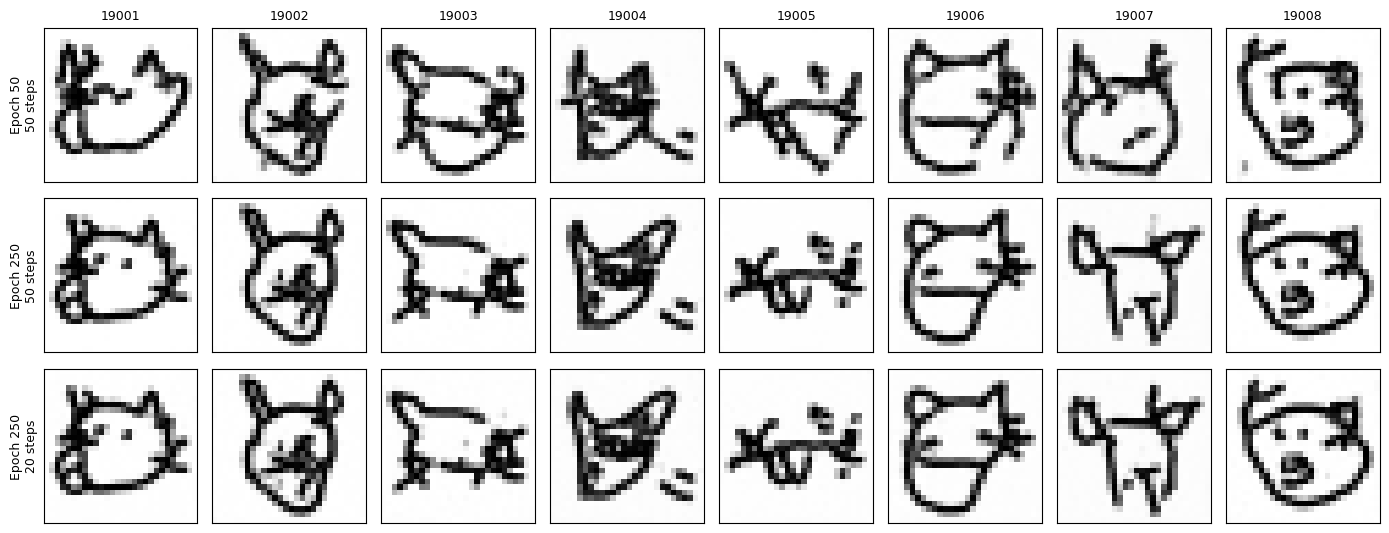

In [34]:
if not ANALYSIS_READY:
    print('Complete scoring and analysis first. Configuration labels remain concealed.')
else:
    FULL=RUN/'labelled_grids';FULL.mkdir(exist_ok=True)
    for name,epoch,steps in CONFIGS:
        for start in range(0,64,16):
            fig,axes=plt.subplots(4,4,figsize=(8,8))
            for i,ax in enumerate(axes.flat,start):
                ax.imshow(np.clip((arrays[name][i,0]+1)/2,0,1),cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
                ax.set_title(str(SEEDS[i]));ax.axis('off')
            fig.suptitle(f'{name} | seeds {SEEDS[start]}-{SEEDS[start+15]}')
            fig.tight_layout();fig.savefig(FULL/f'{name}_page{start//16+1}.png',dpi=160);plt.close(fig)
    # Fixed first eight seeds, not selected on quality. Preserve all full grids above.
    fig,axes=plt.subplots(3,8,figsize=(14,5.5))
    for row,(name,epoch,steps) in enumerate(CONFIGS):
        for col in range(8):
            ax=axes[row,col];ax.imshow(np.clip((arrays[name][col,0]+1)/2,0,1),cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
            ax.set_xticks([]);ax.set_yticks([])
            if row==0:ax.set_title(str(SEEDS[col]),fontsize=9)
            if col==0:ax.set_ylabel(f'Epoch {epoch}\n{steps} steps',fontsize=9)
    fig.tight_layout();fig.savefig(RUN/'matched_first8.png',dpi=180);plt.show();plt.close(fig)

## 8. Personal interpretation and export
Compare your recorded predictions with the new results. Explain uncertain differences honestly and name at least one failure. Complete one independent check using a source you actually consult. For example, derive the target velocity or verify the paired-difference calculation by hand for a few seeds. These fields document work you actually do; the notebook never fills them on your behalf.

Export is allowed before scoring is finished so you can save progress, but the archive status will say **INCOMPLETE**. For final review, finish scoring, analysis and personal notes, then export again. Download this executed notebook separately from Colab's File menu.

In [35]:
OBSERVATION_VS_TRAINING_PREDICTION = ''
OBSERVATION_VS_STEPS_PREDICTION = ''
FAILURE_OR_LIMITATION = ''
MY_INDEPENDENT_CHECK_AND_SOURCE = ''
MY_NEXT_DECISION = ''
reflection={'recorded_utc':utc_now(),'training_prediction_vs_observation':OBSERVATION_VS_TRAINING_PREDICTION,
            'steps_prediction_vs_observation':OBSERVATION_VS_STEPS_PREDICTION,
            'failure_or_limitation':FAILURE_OR_LIMITATION,'independent_check_and_source':MY_INDEPENDENT_CHECK_AND_SOURCE,
            'next_decision':MY_NEXT_DECISION}
reflection_path=RUN/'student_reflection.json'
if all(str(v).strip() for k,v in reflection.items() if k!='recorded_utc'):
    save_json(reflection_path,reflection)
elif reflection_path.exists():
    print('Existing personal reflection preserved; blank notebook fields did not overwrite it.')
else:
    print('Personal reflection still incomplete. Fill all five fields before final submission.')

# Avoid treating an old analysis as current after a rating was edited.
analysis_path=RUN/'analysis_provenance.json'
analysis_current=analysis_path.exists() and json.loads(analysis_path.read_text())['ratings_sha256']==digest(ratings_path)
complete=bool(analysis_current and reflection_path.exists())
status={'status':'COMPLETE_FOR_REVIEW' if complete else 'INCOMPLETE',
        'exported_utc':utc_now(),'analysis_matches_current_ratings':analysis_current,
        'personal_reflection_present':reflection_path.exists()}
save_json(RUN/'export_status.json',status)
(RUN/'README.txt').write_text('COMP6010 C2 fresh 64-seed follow-up evaluation.\n'
    'Read export_status.json first. Original experiments remain unchanged.\n'
    'protocol.json: pre-generation follow-up predictions, seeds and rubric.\n'
    'generation_complete.json: device/versions/checkpoint-linked protocol and array hashes.\n'
    'human_ratings.csv: actual rater entries; configuration key joins IDs to configs/seeds.\n'
    'quality_summary.csv: Wilson intervals conditional on model/rater.\n'
    'paired_comparisons.csv: 20000 seed-paired percentile bootstrap resamples; not an equivalence test.\n'
    'timing_repeats.csv: five rounds, batch16, all64 images per timed evaluation.\n'
    'blinded_grids and labelled_grids: full image sets; arrays remain unclipped.\n'
    'Checkpoints are referenced by hashes; original checkpoint ZIP is still required for reproduction.\n'
    'Student must save the executed notebook separately. No new training was performed.\n')
archive=BASE/f'{RUN_NAME}_results.zip'
with zipfile.ZipFile(archive,'w',zipfile.ZIP_DEFLATED) as z:
    for path in sorted(RUN.rglob('*')):
        if path.is_file() and 'restored_checkpoints' not in path.parts and path.suffix!='.tmp':
            z.write(path,path.relative_to(RUN))
print('Export status:',status)
print('Archive:',archive)
DOWNLOAD_RESULTS=True
if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
        files.download(str(archive))
    except ImportError:
        print('Download the archive from the displayed path.')

Personal reflection still incomplete. Fill all five fields before final submission.
Export status: {'status': 'INCOMPLETE', 'exported_utc': '2026-09-28T04:25:16.926011+00:00', 'analysis_matches_current_ratings': True, 'personal_reflection_present': False}
Archive: /content/drive/MyDrive/COMP6010/cat_eval64_v1_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>